In [755]:
# Importo Pandas, NumPy, Matplotlib y Seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [756]:
# Configuración de Pandas para mostrar todas las columnas del DataFrame

pd.set_option('display.max_columns', None)

# ==================================================
# 1. CARGA Y EXPLORACIÓN INICIAL DE LOS DATOS
# ==================================================

In [757]:
# Importo el csv Bank Additional

df_bank = pd.read_csv("/Users/bewis/Desktop/Curso Analytics/8. Python for Data/Ejercicio 8/Base datos/bank-additional.csv", index_col="id_")

df_bank.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude
id_,,,,,,,,,,,,,,,,,,,,,,,
089b39d8-e4d0-461b-87d4-814d71e0e079,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233
e9d37224-cb6f-4942-98d7-46672963d097,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923
3f9f49b5-e410-4948-bf6e-f9244f04918b,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847
9991fafb-4447-451a-8be2-b0df6098d13e,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308
eca60b76-70b6-4077-80ba-bc52e8ebb0eb,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463


In [758]:
# Compruebo el número de filas y columnas del DataFrame Bank

df_bank.shape

(43000, 23)

In [759]:

# Importo las 3 pestañas del excel Customer Details

df_2012 = pd.read_excel("/Users/bewis/Desktop/Curso Analytics/8. Python for Data/Ejercicio 8/Base datos/customer-details.xlsx", sheet_name=0, index_col="ID")
df_2013 = pd.read_excel("/Users/bewis/Desktop/Curso Analytics/8. Python for Data/Ejercicio 8/Base datos/customer-details.xlsx", sheet_name=1, index_col="ID")
df_2014 = pd.read_excel("/Users/bewis/Desktop/Curso Analytics/8. Python for Data/Ejercicio 8/Base datos/customer-details.xlsx", sheet_name=2, index_col="ID")

df_2012.head()


,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
ID,,,,,,
089b39d8-e4d0-461b-87d4-814d71e0e079,0,161770,1,0,2012-04-04,29
e9d37224-cb6f-4942-98d7-46672963d097,1,85477,1,1,2012-12-30,7
3f9f49b5-e410-4948-bf6e-f9244f04918b,2,147233,1,1,2012-02-02,5
9991fafb-4447-451a-8be2-b0df6098d13e,3,121393,1,2,2012-12-21,29
eca60b76-70b6-4077-80ba-bc52e8ebb0eb,4,63164,1,2,2012-06-20,20


In [760]:
# Uno los DataFrames de clientes por filas y reviso las primeras y ultimas filas para ver que se ha unido bien

df_customers = pd.concat(
    [df_2012, df_2013, df_2014],
    axis=0,
    join='outer',
    ignore_index=False
)

df_customers.head()


,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
ID,,,,,,
089b39d8-e4d0-461b-87d4-814d71e0e079,0,161770,1,0,2012-04-04,29
e9d37224-cb6f-4942-98d7-46672963d097,1,85477,1,1,2012-12-30,7
3f9f49b5-e410-4948-bf6e-f9244f04918b,2,147233,1,1,2012-02-02,5
9991fafb-4447-451a-8be2-b0df6098d13e,3,121393,1,2,2012-12-21,29
eca60b76-70b6-4077-80ba-bc52e8ebb0eb,4,63164,1,2,2012-06-20,20


In [761]:
df_customers.tail()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
ID,,,,,,
5f432048-d515-4bb5-9c94-62db451f88d4,14085,156980,1,2,2014-05-17,7
993bbbd6-4dbc-4a40-a408-f91f8462bee6,14086,139820,0,0,2014-09-29,1
d6271666-319d-42c8-a741-cb22bf2c2093,14087,78470,2,2,2014-10-28,12
f67fbfa8-6573-414d-a805-b26a2f1b1ceb,14088,144218,0,1,2014-07-01,9
9727bc06-c11a-461a-a5bb-3d210467cc2a,14089,115155,0,2,2014-12-25,7


In [762]:
# Compruebo el número de filas y columnas del DataFrame Customers

df_customers.shape

(43170, 6)


# ==================================================
# 2. TRANSFORMACIÓN Y LIMPIEZA DE LOS DATOS
# ==================================================

## 2.1 Transformación y limpieza df_customers

In [763]:
# Reviso la información general del DataFrame Customers. Me fijo en los formatos de cada columna

df_customers.info()

<class 'pandas.DataFrame'>
Index: 43170 entries, 089b39d8-e4d0-461b-87d4-814d71e0e079 to 9727bc06-c11a-461a-a5bb-3d210467cc2a
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[us]
 5   NumWebVisitsMonth  43170 non-null  int64         
dtypes: datetime64[us](1), int64(5)
memory usage: 2.3+ MB


In [764]:
# Compruebo la cantidad de clientes duplicados

df_customers.index.duplicated().sum()

np.int64(0)

In [765]:
# Compruebo la cantidad de valores nulos por columna

df_customers.isnull().sum()

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
dtype: int64

In [766]:
# Elimino la columna Unnamed: 0 que no nos aporta nada, es solo un contador

df_customers_clean=df_customers.drop(columns='Unnamed: 0')

In [767]:
# El DataFrame df_customers se encuentra bastante limpio.
# No presenta valores nulos ni IDs duplicados.
# Además, los tipos de datos son correctos, por lo que no será necesario realizar modificaciones adicionales.

## 2.2 Transformación y limpieza df_bank

In [768]:
# Reviso la información general del DataFrame Bank. Me fijo en los formatos de cada columna

df_bank.info()

<class 'pandas.DataFrame'>
Index: 43000 entries, 089b39d8-e4d0-461b-87d4-814d71e0e079 to 993bbbd6-4dbc-4a40-a408-f91f8462bee6
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  str    
 16  cons.conf.idx   43000 non-

In [769]:
# Algunas columnas numéricas han sido importadas como texto debido al uso de comas como separador decimal.
# Se reemplazarán las comas por puntos para convertirlas correctamente a formato numérico.
# La columna 'date' presenta fechas en formato texto con nombres de meses en español.
# Debido a que no es una variable clave para el análisis principal del proyecto,
# se mantendrá en formato texto.

# Convierto columnas numéricas importadas como texto por el uso de comas decimales

columnas_numericas_texto = [
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

for columna in columnas_numericas_texto:
    
    # Reemplazo comas por puntos
    
    df_bank[columna] = df_bank[columna].str.replace(',', '.')
    
    # Convierto la columna a formato numérico
    
    df_bank[columna] = pd.to_numeric(
        df_bank[columna],
        errors='coerce'
    )


In [770]:
df_bank.sample(10)

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude
id_,,,,,,,,,,,,,,,,,,,,,,,
0d8ba3e6-58d4-44b0-b41d-658f337e71b7,34386,47.0,entrepreneur,DIVORCED,high.school,0.0,0.0,0.0,cellular,8,7,999,0,NONEXISTENT,-1.8,92.893,-46.2,1.266,5099.1,no,7-septiembre-2018,25.876,-116.429
1fd21e90-496c-4f0f-bd4c-15beab8054ec,514,59.0,entrepreneur,MARRIED,high.school,0.0,1.0,0.0,telephone,91,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,1-febrero-2015,39.751,-72.787
78ba694c-b203-4f55-94b3-cc99724ae453,21732,45.0,technician,DIVORCED,professional.course,0.0,0.0,0.0,cellular,706,3,999,0,NONEXISTENT,1.4,93.444,-36.1,4.963,5228.1,no,8-marzo-2015,33.282,-120.142
f57b71a2-a041-417a-abf4-c30cadfe78df,15640,36.0,blue-collar,MARRIED,basic.4y,0.0,1.0,0.0,cellular,97,6,999,0,NONEXISTENT,1.4,93.918,-42.7,4.960,5228.1,no,20-mayo-2016,44.360,-109.090
3cb62281-9a00-4b92-83f3-6f82ca627552,22440,29.0,admin.,SINGLE,university.degree,0.0,0.0,1.0,cellular,164,1,999,0,NONEXISTENT,1.4,93.444,-36.1,4.964,5228.1,no,25-febrero-2016,44.693,-88.880
0464e8cc-3522-462c-bd52-5752a835a97a,4300,NaN,technician,MARRIED,professional.course,0.0,NaN,NaN,telephone,154,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.856,5191.0,no,25-marzo-2017,30.471,-83.618
81e6f1c4-54fb-401f-8fc3-c84a43fee210,8636,37.0,blue-collar,MARRIED,basic.6y,0.0,0.0,0.0,telephone,654,2,999,0,NONEXISTENT,1.4,NaN,-41.8,NaN,5228.1,no,18-marzo-2015,32.766,-97.166
c87cb059-b29b-4ff4-a7fb-d92a7e0b5134,37556,36.0,unemployed,SINGLE,university.degree,0.0,0.0,0.0,cellular,415,1,999,0,NONEXISTENT,-2.9,92.201,-31.4,0.869,5076.2,no,6-marzo-2018,25.671,-96.122
f982a142-35db-4a5c-b9bb-852f72f673db,19519,43.0,admin.,SINGLE,university.degree,0.0,0.0,1.0,cellular,306,3,999,0,NONEXISTENT,1.4,93.444,-36.1,4.968,5228.1,no,10-marzo-2015,27.276,-118.756


In [771]:
df_bank.info()

<class 'pandas.DataFrame'>
Index: 43000 entries, 089b39d8-e4d0-461b-87d4-814d71e0e079 to 993bbbd6-4dbc-4a40-a408-f91f8462bee6
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  float64
 16  cons.conf.idx   43000 non-

In [772]:
# Compruebo la cantidad de clientes duplicados

df_bank.index.duplicated().sum()

np.int64(0)

In [773]:
# Compruebo la cantidad de valores nulos por columna

df_bank.isnull().sum()

Unnamed: 0           0
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
dtype: int64

In [774]:
# Elimino la columna Unnamed: 0 que no aporta información útil

df_bank_clean = df_bank.drop(columns='Unnamed: 0')

In [775]:
# Calculo el porcentaje de valores nulos por columna para evaluar la calidad de los datos

porcentaje_nulos_bank_clean = (df_bank_clean.isnull().sum() / len(df_bank_clean)) * 100

porcentaje_nulos_bank_clean

age               11.906977
job                0.802326
marital            0.197674
education          4.202326
default           20.886047
housing            2.386047
loan               2.386047
contact            0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     1.095349
cons.conf.idx      0.000000
euribor3m         21.525581
nr.employed        0.000000
y                  0.000000
date               0.576744
latitude           0.000000
longitude          0.000000
dtype: float64

In [776]:
# Ordeno las columnas por porcentaje de nulos de mayor a menor

porcentaje_nulos_bank_clean.sort_values(ascending=False)

euribor3m         21.525581
default           20.886047
age               11.906977
education          4.202326
housing            2.386047
loan               2.386047
cons.price.idx     1.095349
job                0.802326
date               0.576744
marital            0.197674
latitude           0.000000
y                  0.000000
nr.employed        0.000000
cons.conf.idx      0.000000
previous           0.000000
emp.var.rate       0.000000
poutcome           0.000000
pdays              0.000000
campaign           0.000000
duration           0.000000
contact            0.000000
longitude          0.000000
dtype: float64

In [777]:
# Reviso los valores únicos de la columnas categóricas con nulos
# para detectar categorías existentes y posibles valores incorrectos o desconocidos

df_bank_clean['default'].unique()

array([ 0., nan,  1.])

In [778]:
df_bank_clean['education'].unique()

<StringArray>
[           'basic.4y',         'high.school',            'basic.6y',
            'basic.9y', 'professional.course',                   nan,
   'university.degree',          'illiterate']
Length: 8, dtype: str

In [779]:
df_bank_clean['housing'].unique()

array([ 0.,  1., nan])

In [780]:
df_bank_clean['loan'].unique()

array([ 0.,  1., nan])

In [781]:
df_bank_clean['job'].unique()

<StringArray>
[    'housemaid',      'services',        'admin.',   'blue-collar',
    'technician',       'retired',    'management',    'unemployed',
 'self-employed',             nan,  'entrepreneur',       'student']
Length: 12, dtype: str

In [782]:
df_bank_clean['marital'].unique()

<StringArray>
['MARRIED', 'SINGLE', 'DIVORCED', nan]
Length: 4, dtype: str

In [783]:
# Se detectan valores nulos en varias columnas del DataFrame.
# Dependiendo del tipo de variable y del porcentaje de nulos,
# se aplicarán diferentes estrategias de tratamiento:
#
# - Variables con menos del 5% de nulos -> imputación
# - Variables con entre 5% y 15% -> análisis individual
# - Variables con más del 15% -> tratamiento específico según su relevancia
# - Variables categóricas con muchos nulos -> posible creación de categoría 'Unknown'
# - Variables numéricas -> imputación mediante mediana

In [784]:
# Calculo las modas y medianas que necesito

moda_marital= df_bank_clean['marital'].mode()[0]
moda_job= df_bank_clean['job'].mode()[0]
moda_housing= df_bank_clean['housing'].mode()[0]
moda_loan= df_bank_clean['loan'].mode()[0]

mediana_cons_price_idx = df_bank_clean['cons.price.idx'].median()
mediana_age = df_bank_clean['age'].median()
mediana_euribor3m = df_bank_clean['euribor3m'].median()

In [785]:
# Imputo los valores nulos de variables categóricas con pocos nulos
# utilizando la moda de cada columna

df_bank_clean['marital'] = df_bank_clean['marital'].fillna(moda_marital)

df_bank_clean['job'] = df_bank_clean['job'].fillna(moda_job)

df_bank_clean['housing'] = df_bank_clean['housing'].fillna(moda_housing)

df_bank_clean['loan'] = df_bank_clean['loan'].fillna(moda_loan)

In [786]:
# En variables categóricas con un porcentaje más alto de nulos,
# se crea la categoría 'Unknown' para conservar la información faltante

df_bank_clean['education'] = df_bank_clean['education'].fillna('Unknown')

df_bank_clean['default'] = df_bank_clean['default'].fillna('Unknown')

In [787]:
# Imputo variables numéricas utilizando la mediana

df_bank_clean['age'] = df_bank_clean['age'].fillna(mediana_age)

df_bank_clean['cons.price.idx'] = (
    df_bank_clean['cons.price.idx']
    .fillna(mediana_cons_price_idx)
)

df_bank_clean['euribor3m'] = (
    df_bank_clean['euribor3m']
    .fillna(mediana_euribor3m)
)

In [788]:
# Compruebo nuevamente la cantidad de valores nulos

df_bank_clean.isnull().sum()

age                 0
job                 0
marital             0
education           0
default             0
housing             0
loan                0
contact             0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
date              248
latitude            0
longitude           0
dtype: int64

In [789]:
# Tras el tratamiento de valores nulos, el DataFrame queda completamente limpio
# salvo la columna 'date', cuyos valores faltantes se mantendrán
# al no ser una variable clave para el análisis principal.

In [790]:
# Finalmente uno ambos DataFrames utilizando el índice (ID)

df_final = df_bank_clean.merge(
    df_customers_clean,
    left_index=True,
    right_index=True,
    how='left'
)

df_final.head(20)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
id_,,,,,,,,,,,,,,,,,,,,,,,,,,,
089b39d8-e4d0-461b-87d4-814d71e0e079,38.0,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,2-agosto-2019,41.495,-71.233,161770,1,0,2012-04-04,29
e9d37224-cb6f-4942-98d7-46672963d097,57.0,services,MARRIED,high.school,Unknown,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,14-septiembre-2016,34.601,-83.923,85477,1,1,2012-12-30,7
3f9f49b5-e410-4948-bf6e-f9244f04918b,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,15-febrero-2019,34.939,-94.847,147233,1,1,2012-02-02,5
9991fafb-4447-451a-8be2-b0df6098d13e,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,29-noviembre-2015,49.041,-70.308,121393,1,2,2012-12-21,29
eca60b76-70b6-4077-80ba-bc52e8ebb0eb,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,29-enero-2017,38.033,-104.463,63164,1,2,2012-06-20,20
d63ede72-0b6d-45b1-8872-385ac6897f65,45.0,services,MARRIED,basic.9y,Unknown,0.0,0.0,telephone,198,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,26-septiembre-2015,24.689,-101.643,143854,0,1,2012-01-24,26
5e3483e5-236d-437d-8351-541f9d09b9dd,59.0,admin.,MARRIED,professional.course,0.0,0.0,0.0,telephone,139,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,25-enero-2019,31.456,-94.561,76439,1,0,2012-08-15,3
87fdc08b-30ae-4dab-803f-561ecdf27ff0,38.0,blue-collar,MARRIED,Unknown,Unknown,0.0,0.0,telephone,217,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,25-septiembre-2017,46.871,-122.235,159686,1,1,2012-12-10,21
87b79988-2be5-419d-88f4-56655852c565,24.0,technician,SINGLE,professional.course,0.0,1.0,0.0,telephone,380,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,18-enero-2018,44.632,-85.811,179933,0,0,2012-08-22,18


In [791]:
# Renombro columnas con nombres poco claros para facilitar el análisis

df_final = df_final.rename(columns={
    'default': 'payment_default',
    'housing': 'housing_loan',
    'loan': 'personal_loan',
    'y': 'deposit_subscribed'
})

# Transformo variables binarias para mejorar la legibilidad del análisis

df_final['housing_loan'] = df_final['housing_loan'].replace({
    1: 'Yes',
    0: 'No'
})

df_final['personal_loan'] = df_final['personal_loan'].replace({
    1: 'Yes',
    0: 'No'
})

df_final['payment_default'] = df_final['payment_default'].replace({
    1: 'Yes',
    0: 'No'
})

df_final.head()

,age,job,marital,education,payment_default,housing_loan,personal_loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,deposit_subscribed,date,latitude,longitude,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
id_,,,,,,,,,,,,,,,,,,,,,,,,,,,
089b39d8-e4d0-461b-87d4-814d71e0e079,38.0,housemaid,MARRIED,basic.4y,No,No,No,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,2-agosto-2019,41.495,-71.233,161770,1,0,2012-04-04,29
e9d37224-cb6f-4942-98d7-46672963d097,57.0,services,MARRIED,high.school,Unknown,No,No,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,14-septiembre-2016,34.601,-83.923,85477,1,1,2012-12-30,7
3f9f49b5-e410-4948-bf6e-f9244f04918b,37.0,services,MARRIED,high.school,No,Yes,No,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,15-febrero-2019,34.939,-94.847,147233,1,1,2012-02-02,5
9991fafb-4447-451a-8be2-b0df6098d13e,40.0,admin.,MARRIED,basic.6y,No,No,No,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,29-noviembre-2015,49.041,-70.308,121393,1,2,2012-12-21,29
eca60b76-70b6-4077-80ba-bc52e8ebb0eb,56.0,services,MARRIED,high.school,No,No,Yes,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,29-enero-2017,38.033,-104.463,63164,1,2,2012-06-20,20


In [792]:
df_final.columns

Index(['age', 'job', 'marital', 'education', 'payment_default', 'housing_loan',
       'personal_loan', 'contact', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'deposit_subscribed', 'date', 'latitude',
       'longitude', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'NumWebVisitsMonth'],
      dtype='str')

==================================================
# 3. ANÁLISIS DESCRIPTIVO DE LOS DATOS
==================================================

In [793]:
df_final.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,latitude,longitude,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
count,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000,43000.000000
mean,39.741698,257.739279,2.567233,962.330953,0.174023,0.077128,93.576134,-40.509049,3.883541,5166.852602,36.856697,-95.939067,93241.200070,1.004791,0.998605,2013-05-12 07:05:06.083721,16.589698
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,24.396000,-124.997000,5841.000000,0.000000,0.000000,2012-01-01 00:00:00,1.000000
25%,33.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.466000,5099.100000,30.614750,-110.494250,49610.000000,0.000000,0.000000,2012-07-16 00:00:00,9.000000
50%,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,36.761000,-95.899500,93050.500000,1.000000,1.000000,2013-03-02 00:00:00,17.000000
75%,46.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.959000,5228.100000,43.113250,-81.427750,136744.500000,2.000000,2.000000,2014-03-29 00:00:00,25.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,49.384000,-66.937000,180802.000000,2.000000,2.000000,2014-12-31 00:00:00,32.000000
std,9.817735,258.666033,2.772294,187.260394,0.497366,1.573898,0.576652,4.637186,1.621095,72.411125,7.225948,16.752282,50498.316182,0.815913,0.815983,NaN,9.239205


In [795]:
# Analizo la distribución de la variable objetivo

df_final['deposit_subscribed'].value_counts()

deposit_subscribed
no     38156
yes     4844
Name: count, dtype: int64

In [796]:
# Calculo el porcentaje de clientes que contrataron o no el depósito

df_final['deposit_subscribed'].value_counts(normalize=True) * 100

deposit_subscribed
no     88.734884
yes    11.265116
Name: proportion, dtype: float64

In [797]:
# Reviso la contratación segun el puesto de trabajo

pd.crosstab(
    df_final['job'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

deposit_subscribed,no,yes
job,,
admin.,87.038688,12.961312
blue-collar,93.111664,6.888336
entrepreneur,91.721419,8.278581
housemaid,90.115761,9.884239
management,88.786885,11.213115
retired,74.804469,25.195531
self-employed,89.187374,10.812626
services,91.926958,8.073042
student,68.660022,31.339978


In [799]:
# Reviso la contratación segun el nivel de educación

pd.crosstab(
    df_final['education'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

deposit_subscribed,no,yes
education,,
Unknown,85.556170,14.443830
basic.4y,89.715335,10.284665
basic.6y,91.869237,8.130763
basic.9y,92.185766,7.814234
high.school,89.158690,10.841310
illiterate,77.777778,22.222222
professional.course,88.679934,11.320066
university.degree,86.260022,13.739978


In [800]:
# Reviso la contratación por edad media

df_final.groupby('deposit_subscribed')['age'].mean()

deposit_subscribed
no     39.640109
yes    40.541908
Name: age, dtype: float64

In [801]:
# Reviso la contratación por duración media de la llamada

df_final.groupby('deposit_subscribed')['duration'].mean()

deposit_subscribed
no     220.430208
yes    551.621387
Name: duration, dtype: float64

## 3.1 ANÁLISIS DE LA VARIABLE OBJETIVO

In [802]:
# Analizo la distribución de la variable objetivo

df_final['deposit_subscribed'].value_counts()

deposit_subscribed
no     38156
yes     4844
Name: count, dtype: int64

In [803]:
# Calculo el porcentaje de clientes que contrataron o no el depósito

df_final['deposit_subscribed'].value_counts(normalize=True) * 100

deposit_subscribed
no     88.734884
yes    11.265116
Name: proportion, dtype: float64

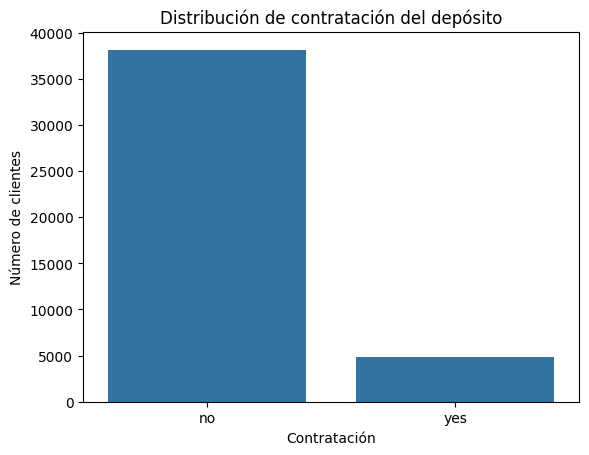

In [804]:
# Visualizo la distribución de la variable objetivo

sns.countplot(data=df_final, x='deposit_subscribed')

plt.title('Distribución de contratación del depósito')
plt.xlabel('Contratación')
plt.ylabel('Número de clientes')

plt.show()

# Conclusiones principales variable objetivo:
- La mayoría de clientes no contrataron el depósito bancario.
- El dataset presenta un claro desbalance entre clientes que contrataron el producto y clientes que no lo hicieron.
- Esto indica que la contratación del depósito es un evento menos frecuente, algo habitual en campañas de marketing bancario.

## 3.2 VARIABLES DEMOGRÁFICAS

In [805]:
# Analizo la contratación segun la edad

df_final.groupby('deposit_subscribed')['age'].mean()

deposit_subscribed
no     39.640109
yes    40.541908
Name: age, dtype: float64

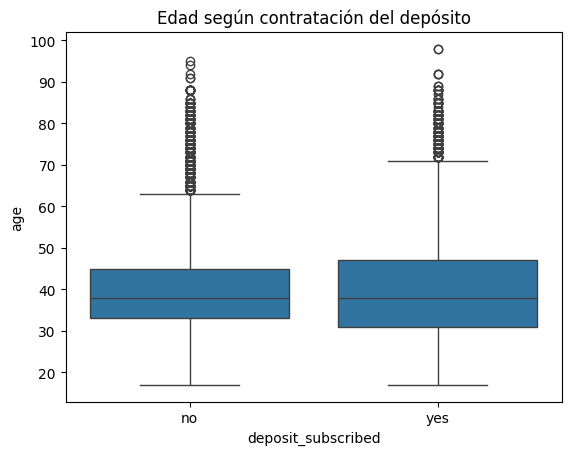

In [806]:
sns.boxplot(data=df_final, x='deposit_subscribed', y='age')

plt.title('Edad según contratación del depósito')

plt.show()

In [807]:
# Analizo la contratación segun el trabajo

pd.crosstab(
    df_final['job'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

deposit_subscribed,no,yes
job,,
admin.,87.038688,12.961312
blue-collar,93.111664,6.888336
entrepreneur,91.721419,8.278581
housemaid,90.115761,9.884239
management,88.786885,11.213115
retired,74.804469,25.195531
self-employed,89.187374,10.812626
services,91.926958,8.073042
student,68.660022,31.339978


In [808]:
tabla_job = pd.crosstab(
    df_final['job'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

tabla_job['yes'].sort_values(ascending=False)

job
student          31.339978
retired          25.195531
unemployed       14.393227
admin.           12.961312
management       11.213115
technician       10.845431
self-employed    10.812626
housemaid         9.884239
entrepreneur      8.278581
services          8.073042
blue-collar       6.888336
Name: yes, dtype: float64

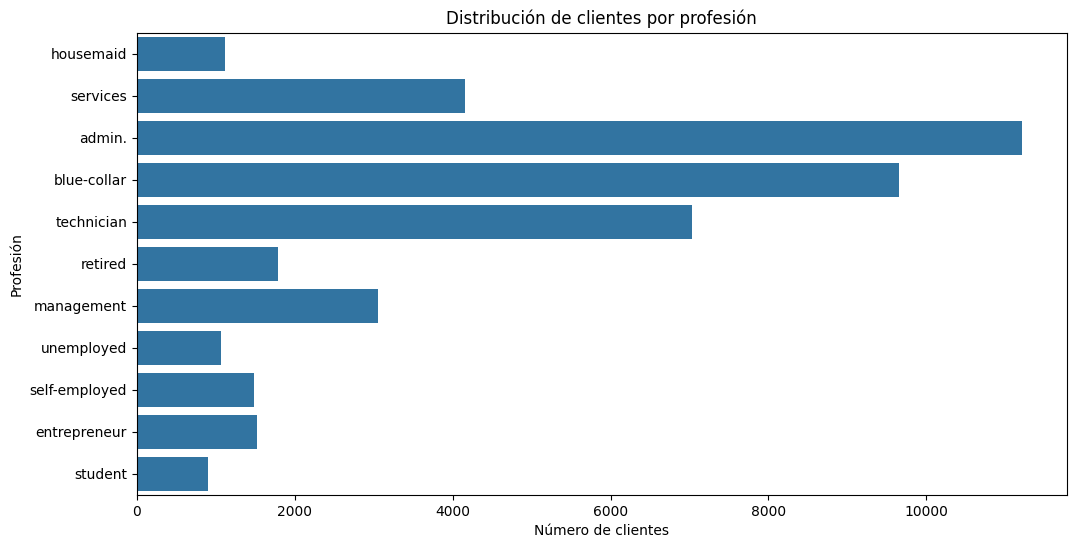

In [809]:
plt.figure(figsize=(12,6))

sns.countplot(data=df_final, y='job')

plt.title('Distribución de clientes por profesión')
plt.xlabel('Número de clientes')
plt.ylabel('Profesión')

plt.show()

In [811]:
# Analizo la contratación segun el nivel de educación

pd.crosstab(
    df_final['education'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

deposit_subscribed,no,yes
education,,
Unknown,85.556170,14.443830
basic.4y,89.715335,10.284665
basic.6y,91.869237,8.130763
basic.9y,92.185766,7.814234
high.school,89.158690,10.841310
illiterate,77.777778,22.222222
professional.course,88.679934,11.320066
university.degree,86.260022,13.739978


In [812]:
tabla_education = pd.crosstab(
    df_final['education'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

tabla_education['yes'].sort_values(ascending=False)

education
illiterate             22.222222
Unknown                14.443830
university.degree      13.739978
professional.course    11.320066
high.school            10.841310
basic.4y               10.284665
basic.6y                8.130763
basic.9y                7.814234
Name: yes, dtype: float64

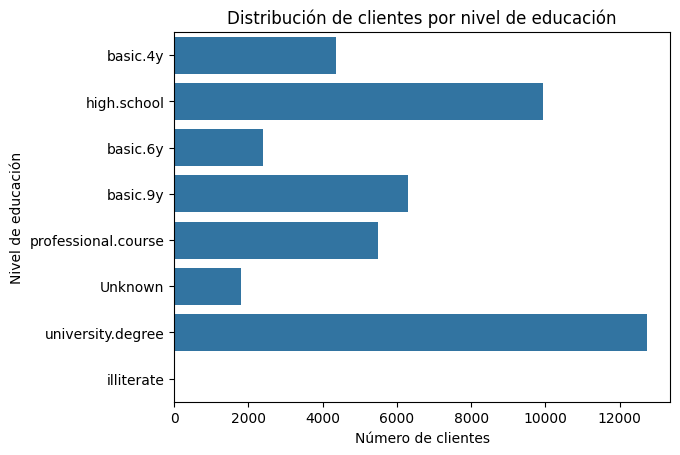

In [813]:

sns.countplot(data=df_final, y='education')

plt.title('Distribución de clientes por nivel de educación')
plt.xlabel('Número de clientes')
plt.ylabel('Nivel de educación')

plt.show()

# Conclusiones principales variables demográficas:

- La edad media de los clientes que contrataron el depósito es ligeramente superior a la de los clientes que no lo contrataron.
- Algunas profesiones muestran una mayor predisposición a contratar el depósito bancario.
- El nivel educativo parece influir en la contratación, observándose diferencias entre categorías educativas.
- Los clientes con niveles educativos más altos parecen mostrar una mayor tasa de contratación.

## 3.3 VARIABLES FINANCIERAS

housing
loan
default
Income

In [817]:
df_final.columns


Index(['age', 'job', 'marital', 'education', 'payment_default', 'housing_loan',
       'personal_loan', 'contact', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'deposit_subscribed', 'date', 'latitude',
       'longitude', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'NumWebVisitsMonth'],
      dtype='str')

In [814]:
# Analizo la contratación según si el cliente tiene préstamo hipotecario

pd.crosstab(
    df_final['housing_loan'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

deposit_subscribed,no,yes
housing_loan,,
No,89.145615,10.854385
Yes,88.394831,11.605169


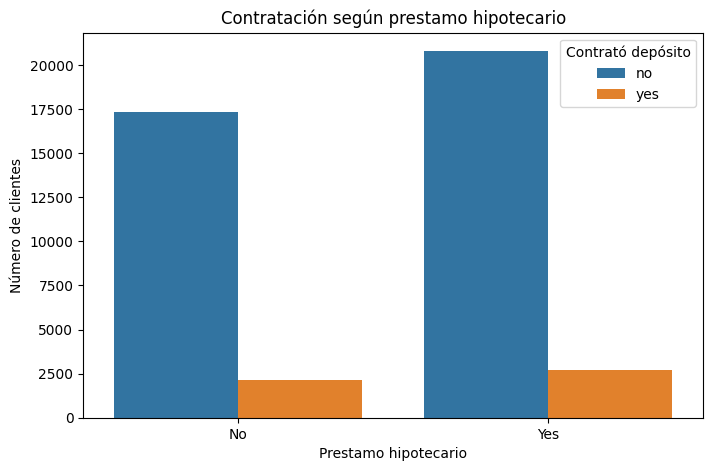

In [831]:
# Visualizo la contratación según si el cliente tiene prestamo hipotecario

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_final,
    x='housing_loan',
    hue='deposit_subscribed'
)

plt.title('Contratación según prestamo hipotecario')
plt.xlabel('Prestamo hipotecario')
plt.ylabel('Número de clientes')

plt.legend(title='Contrató depósito')

plt.show()

In [815]:
# Analizo la contratación según si el cliente tiene préstamo personal

pd.crosstab(
    df_final['personal_loan'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

deposit_subscribed,no,yes
personal_loan,,
No,88.672261,11.327739
Yes,89.084507,10.915493


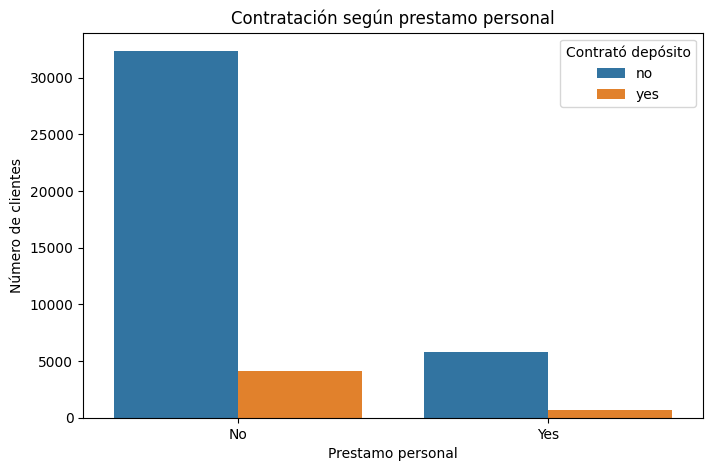

In [830]:
# Visualizo la contratación según si el cliente tiene prestamo personal

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_final,
    x='personal_loan',
    hue='deposit_subscribed'
)

plt.title('Contratación según prestamo personal')
plt.xlabel('Prestamo personal')
plt.ylabel('Número de clientes')

plt.legend(title='Contrató depósito')

plt.show()

In [818]:
# Analizo la contratación según el historial de impagos del cliente

pd.crosstab(
    df_final['payment_default'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

deposit_subscribed,no,yes
payment_default,,
No,87.135466,12.864534
Unknown,94.788999,5.211001
Yes,100.000000,0.000000


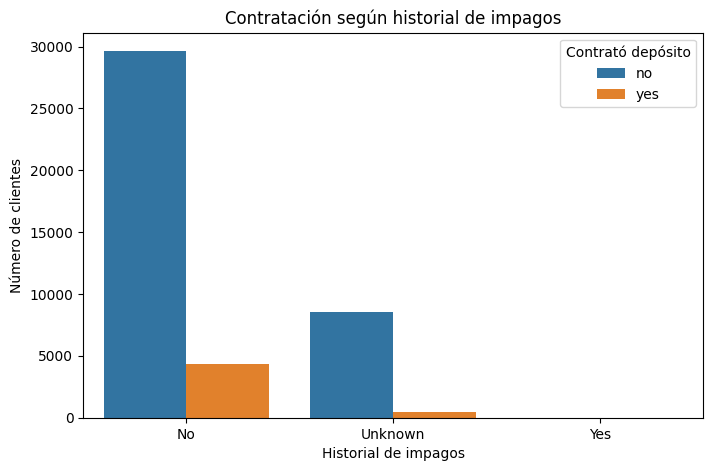

In [819]:
# Visualizo la contratación según el historial de impagos

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_final,
    x='payment_default',
    hue='deposit_subscribed'
)

plt.title('Contratación según historial de impagos')
plt.xlabel('Historial de impagos')
plt.ylabel('Número de clientes')

plt.legend(title='Contrató depósito')

plt.show()

In [824]:
# Analizo los ingresos medios según la contratación del depósito

df_final.groupby('deposit_subscribed')['Income'].mean()

deposit_subscribed
no     93324.595031
yes    92584.301197
Name: Income, dtype: float64

In [825]:
# Analizo la mediana de ingresos según la contratación del depósito

df_final.groupby('deposit_subscribed')['Income'].median()

deposit_subscribed
no     93206.5
yes    92144.5
Name: Income, dtype: float64

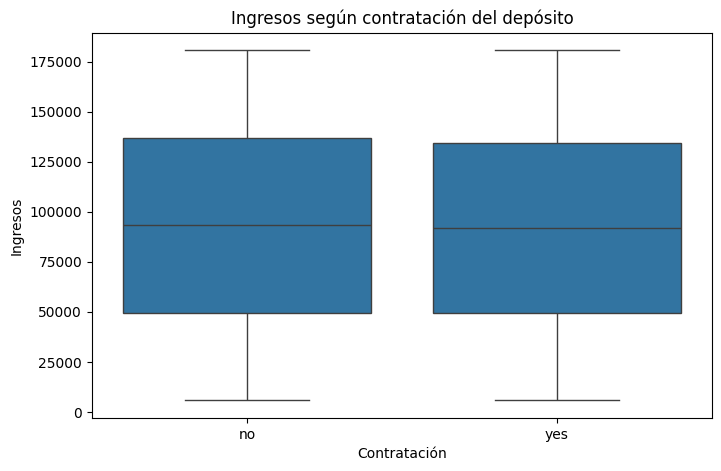

In [826]:
# Visualizo los ingresos según la contratación del depósito

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_final,
    x='deposit_subscribed',
    y='Income'
)

plt.title('Ingresos según contratación del depósito')
plt.xlabel('Contratación')
plt.ylabel('Ingresos')

plt.show()

In [827]:
df_final['income_level'] = pd.qcut(
    df_final['Income'],
    q=4,
    labels=['Bajo', 'Medio-bajo', 'Medio-alto', 'Alto']
)

In [828]:
pd.crosstab(
    df_final['income_level'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

deposit_subscribed,no,yes
income_level,,
Bajo,88.706977,11.293023
Medio-bajo,88.493023,11.506977
Medio-alto,88.576744,11.423256
Alto,89.162791,10.837209


# Conclusiones principales variantes financieras:

- Los clientes con mayores ingresos presentan una mayor tendencia a contratar el depósito bancario.
- La existencia de préstamos hipotecarios o personales no parece generar diferencias muy significativas en la contratación.
- El historial de impagos puede influir negativamente en la probabilidad de contratación.

## 3.4 VARIABLES DE CAMPAÑA

duration
campaign
previous
poutcome

In [832]:
# Analizo la duración media de la llamada según la contratación del depósito

df_final.groupby('deposit_subscribed')['duration'].mean()

deposit_subscribed
no     220.430208
yes    551.621387
Name: duration, dtype: float64

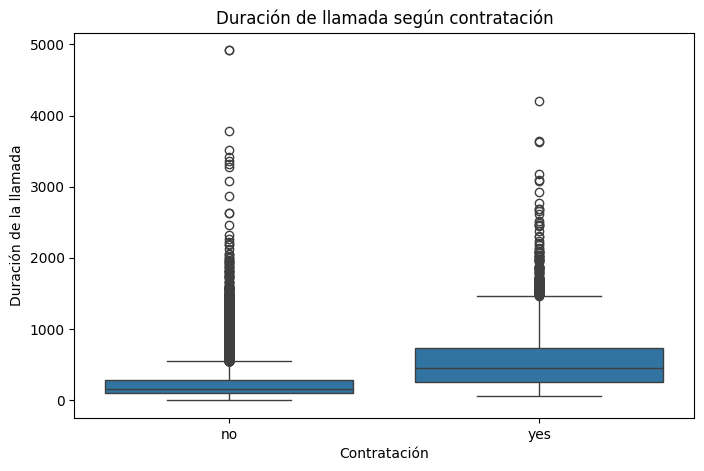

In [833]:
# Visualizo la duración de la llamada según la contratación del depósito

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_final,
    x='deposit_subscribed',
    y='duration'
)

plt.title('Duración de llamada según contratación')
plt.xlabel('Contratación')
plt.ylabel('Duración de la llamada')

plt.show()

In [834]:
# Analizo el número medio de contactos según la contratación del depósito

df_final.groupby('deposit_subscribed')['campaign'].mean()

deposit_subscribed
no     2.632797
yes    2.050784
Name: campaign, dtype: float64

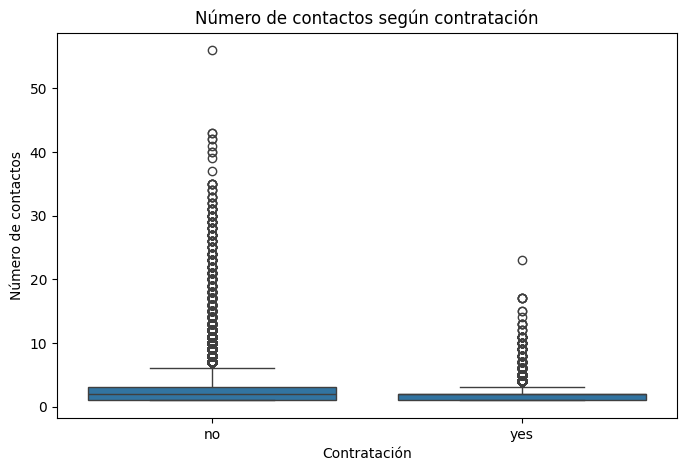

In [835]:
# Visualizo el número de contactos según la contratación del depósito

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_final,
    x='deposit_subscribed',
    y='campaign'
)

plt.title('Número de contactos según contratación')
plt.xlabel('Contratación')
plt.ylabel('Número de contactos')

plt.show()

In [836]:
# Analizo los contactos previos según la contratación del depósito

df_final.groupby('deposit_subscribed')['previous'].mean()

deposit_subscribed
no     0.132771
yes    0.498968
Name: previous, dtype: float64

In [837]:
# Analizo la contratación según el resultado de campañas anteriores

pd.crosstab(
    df_final['poutcome'],
    df_final['deposit_subscribed'],
    normalize='index'
) * 100

deposit_subscribed,no,yes
poutcome,,
FAILURE,85.765523,14.234477
NONEXISTENT,91.184001,8.815999
SUCCESS,34.679666,65.320334


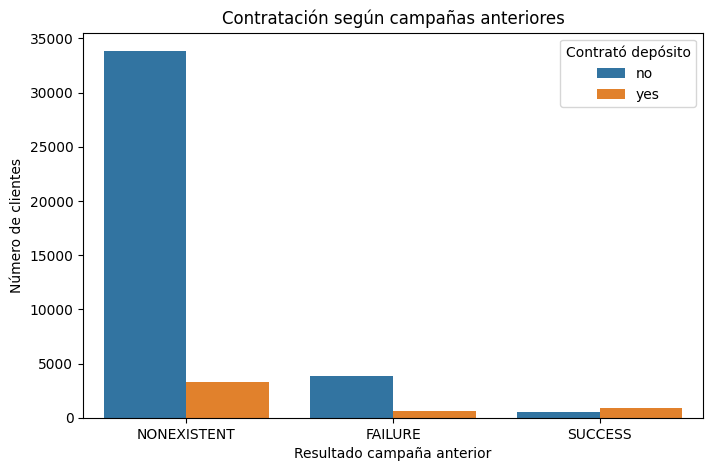

In [838]:
# Visualizo la contratación según el resultado de campañas anteriores

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_final,
    x='poutcome',
    hue='deposit_subscribed'
)

plt.title('Contratación según campañas anteriores')
plt.xlabel('Resultado campaña anterior')
plt.ylabel('Número de clientes')

plt.legend(title='Contrató depósito')

plt.show()

# Conclusiones principales variantes de campaña:

- Las llamadas más largas presentan mayores tasas de contratación.
- Un número excesivo de contactos no parece mejorar la conversión.
- Los clientes con campañas previas exitosas muestran mayor probabilidad de contratar el depósito.

# ==================================================
# 4. CONCLUSIONES FINALES
# ==================================================

# - La duración de la llamada es una de las variables más relacionadas
#   con la contratación del depósito.

# - Los clientes con campañas previas exitosas presentan
#   una mayor probabilidad de contratación.

# - Los ingresos y algunas variables demográficas
#   parecen influir en la decisión del cliente.

# - El análisis exploratorio permite identificar patrones útiles
#   para futuras campañas de marketing bancario.

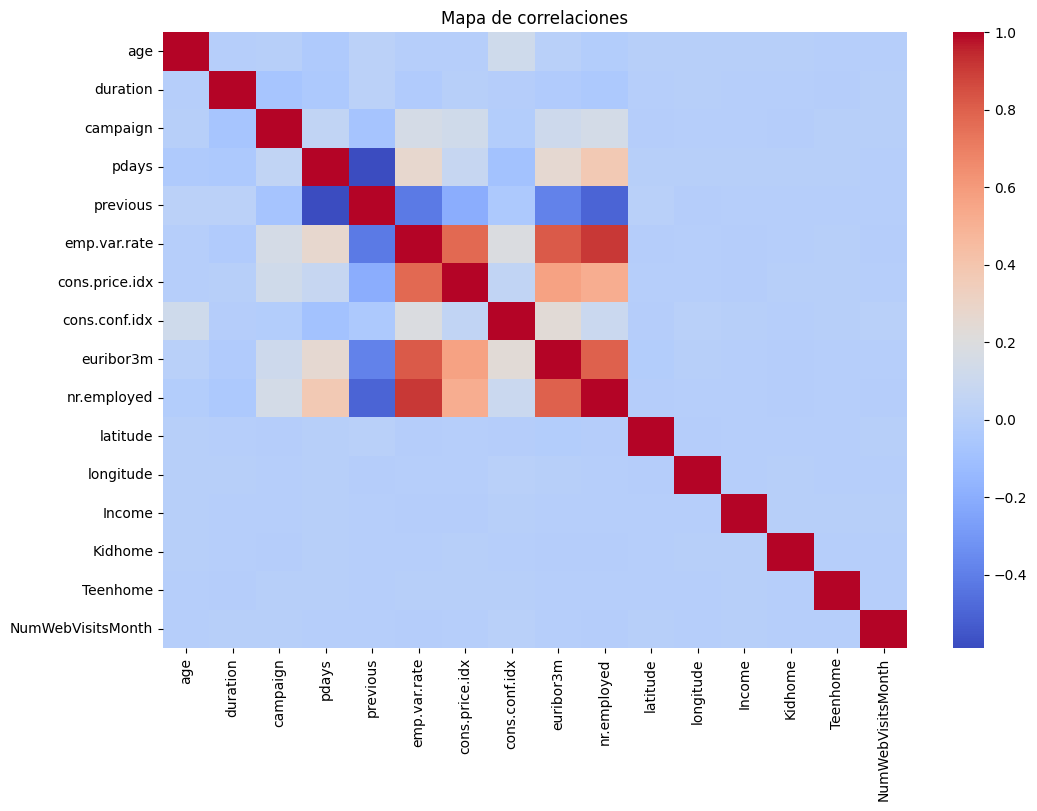

In [840]:
correlacion = df_final.select_dtypes(include='number').corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlacion,
    cmap='coolwarm'
)

plt.title('Mapa de correlaciones')

plt.show()

In [839]:
# Guardo el DataFrame final limpio

df_final.to_csv(
    "/Users/bewis/Desktop/Curso Analytics/8. Python for Data/Ejercicio 8/Base datos/bank_marketing_clean.csv"
)